In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import math
import time
#from Utils99 import *
from Utils_graph import *
from scipy.spatial import distance
import optuna
import sys
import os
from matplotlib.offsetbox import (AnnotationBbox, DrawingArea, OffsetImage,
                                  TextArea)
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.cm as cm  # Certifique-se de importar cm
from scipy.spatial import distance
import re
from scipy.signal import hilbert
from concurrent.futures import ProcessPoolExecutor

fs, FS = 25600,25600

/home/claudio/Área de trabalho/Python/Artigo_J3C/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [155]:
def calculate_mahalanobis(df):
    """
    df: DataFrame onde cada linha é um sample e cada coluna é uma feature 
        (ex: magnitudes de frequências específicas da FFT do envelope)
    """
    
    # 1. Definir a fase de referência (Estado Saudável)
    # Vamos assumir que os primeiros 10 samples representam o rolamento bom
    reference_data = df.iloc[:10]
    
    # 2. Calcular a média e a matriz de covariância do estado saudável
    mu = np.mean(reference_data, axis=0)
    cov = np.cov(reference_data.T)
    
    # Inversa da matriz de covariância (necessária para a fórmula)
    # Usamos a pseudo-inversa (pinv) para evitar erros caso as colunas sejam 
    # linearmente dependentes ou tenham variância zero
    inv_cov = np.linalg.pinv(cov)
    
    mahalanobis_dist = []
    
    # 3. Calcular a distância para cada sample no tempo
    for i in range(len(df)):
        sample = df.iloc[i]
        # Cálculo da distância: sqrt( (x - mu)^T * inv_cov * (x - mu) )
        d = distance.mahalanobis(sample, mu, inv_cov)
        mahalanobis_dist.append(d)
        
    return np.array(mahalanobis_dist)

def smooth_df(df, window=5):
    """
    Leaves the first row untouched.
    Smooths from the second row up to the midpoint.
    Keeps the second half of the data intact.
    """
    # Calculate midpoint
    mid_idx = len(df) // 1
    
    def smooth_column(series):
        # 1. First row (untouched)
        first_row = series.iloc[:1]
        
        # 2. Segment to smooth (from row 2 to midpoint)
        to_smooth = series.iloc[1:mid_idx]
        
        # 3. Second half (untouched)
        second_half = series.iloc[mid_idx:]
        
        # Apply Rolling Mean to the specific segment
        # min_periods=1 handles the edges so we don't get NaNs
        smoothed_segment = to_smooth.rolling(window=window, center=True, min_periods=1).mean()
        
        # Recombine everything in order
        return pd.concat([first_row, smoothed_segment, second_half])

    # Apply to all columns in the DataFrame
    return df.apply(smooth_column)

def mode_select(mode):
    if mode == "RSX_BPFI": return "RSX_BPFI_2"
    elif mode == "RSY_BPFI": return "RSY_BPFI_2"
    elif mode == "RSX_BPFO": return "RSX_BPFO_1"
    elif mode == "RSY_BPFO": return "RSY_BPFO_2"
    elif mode == "RSX_CAGE": return "RSX_CAGE_3"
    elif mode == "RSY_CAGE": return "RSY_CAGE_2"

#Calcula a FFT do envelope do dataframe dos sinais de vibração

In [3]:

def get_envelope_fast(signal, rate):
    """Cálculo otimizado do envelope e FFT."""
    # Hilbert e remoção de DC
    amplitude_envelope = np.abs(hilbert(signal))
    amplitude_envelope -= np.mean(amplitude_envelope)
    
    n = len(signal)
    # FFT (calcula apenas a metade positiva para ganhar tempo)
    fft_data = np.fft.fft(amplitude_envelope)
    fft_abs = np.abs(fft_data[:n // 2]) * (2.0 / n)
    freqs = np.fft.fftfreq(n, 1/rate)[:n // 2]
    
    # Filtro de 0 a 2000Hz
    mask = (freqs >= 0) & (freqs <= 2000)
    return freqs[mask], fft_abs[mask]

def process_single_file(args):
    """
    Função global (sem lambda) para evitar erros de serialização.
    args: (input_p, output_p, rate)
    """
    input_p, output_p, rate = args
    try:
        # 1. Leitura rápida
        df_raw = pd.read_csv(input_p)
        data = df_raw.values
        
        results = {}
        freqs = None
        
        # 2. Processamento por coluna
        for i in range(data.shape[1]):
            freqs, fft_vals = get_envelope_fast(data[:, i], rate)
            results[f'Mode_{i}'] = fft_vals
        
        # 3. Construção do DataFrame final
        df_final = pd.DataFrame(results)
        df_final.insert(0, 'FREQ', freqs)
        
        # 4. Verificação e criação de diretório
        os.makedirs(os.path.dirname(output_p), exist_ok=True)
        
        # 5. Escrita
        df_final.to_csv(output_p, index=False)
        return f"Sucesso: {os.path.basename(input_p)}"
    
    except Exception as e:
        return f"Erro em {input_p}: {str(e)}"

if __name__ == "__main__":
    # Caminhos (Use caminhos absolutos ou verifique as strings)
    base_dir = r"/home/claudio/Área de trabalho/Python/DATASETS/VMD/02_VMDX/"
    out_dir = r"/home/claudio/Área de trabalho/Python/DATASETS/VMD/02_VMDX_FFT/"
    
    if not os.path.exists(base_dir):
        print(f"ERRO: O diretório de entrada não existe: {base_dir}")
        exit()

    tasks = []
    brngs = [b for b in os.listdir(base_dir) if not b.startswith("Bearing5_4")]
    brngs.sort()
    
    for brng in brngs:
        brng_path = os.path.join(base_dir, brng)
        if os.path.isdir(brng_path):
            samples = os.listdir(brng_path)
            # Ordenação numérica
            samples.sort(key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0)
            
            for sample in samples:
                input_p = os.path.join(base_dir, brng, sample)
                output_p = os.path.join(out_dir, brng, sample)
                tasks.append((input_p, output_p, FS))

    print(f"Iniciando processamento de {len(tasks)} arquivos...")

    # Usando o ProcessPoolExecutor de forma correta
    with ProcessPoolExecutor() as executor:
        # O map retorna um gerador, convertemos para lista para forçar a execução e ver os retornos
        resultados = list(executor.map(process_single_file, tasks))
    
    # Exibe os primeiros resultados para conferência
    for r in resultados[:5]:
        print(r)
    print("...")
    print("Processamento concluído.")

Iniciando processamento de 2667 arquivos...
Sucesso: 1.csv
Sucesso: 2.csv
Sucesso: 3.csv
Sucesso: 4.csv
Sucesso: 5.csv
...
Processamento concluído.


#Calcula a soma do espectro das ffts dos sinais de vibraçào consecutivamente e retorna um datraframe com os valores somados

In [58]:
# Pré-compilação do Regex para busca de números
RE_DIGIT = re.compile(r'\d+')

def process_single_bearing(brng, base_dir, out_dir, fs):
    """Função para processar um rolamento individualmente (será rodada em paralelo)"""
    if brng.startswith("Bearing5_4"):
        return f"{brng}: Ignorado"

    path_brng = os.path.join(base_dir, brng)
    samples = os.listdir(path_brng)
    # Ordenação otimizada
    samples.sort(key=lambda x: int(RE_DIGIT.search(x).group()))

    env_list = []
    
    for sample in samples:
        # 1. Leitura rápida (considere passar usecols se souber quais colunas precisa)
        df = pd.read_csv(os.path.join(path_brng, sample))
        
        # 2. Processamento (supondo que df_env seja sua função customizada)
        df = df_env(df, fs)
        
        # 3. Filtro booleano rápido
        mask = (df['FREQ'] >= 0) & (df['FREQ'] <= 2000)
        filtered_df = df.loc[mask]
        #filtered_df = filtered_df**2
        
        # 4. Soma direta no NumPy para evitar overhead de objetos Pandas
        env_list.append(filtered_df.sum(axis=0).values)

    # Consolidação final do rolamento
    if env_list:
        df_final = pd.DataFrame(env_list, columns=df.columns)
        output_path = os.path.join(out_dir, f"{brng}.csv")
        # Exporta apenas as colunas 2 a 6 (índices 2:7)
        df_final.iloc[:, 2:7].to_csv(output_path, index=False)
        return f"{brng}: Processado"

def main():
    base_dir = r"/home/claudio/Área de trabalho/Python/DATASETS/VMD/02_VMDX/"
    out_dir = r"RS4/"
    fs = 25600 # Exemplo de frequência de amostragem
    
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    brngs = [b for b in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, b))]
    brngs.sort()

    print(f"Iniciando processamento paralelo em {os.cpu_count()} núcleos...")

    # Uso de ProcessPoolExecutor para CPU-bound tasks
    with ProcessPoolExecutor() as executor:
        futures = [executor.submit(process_single_bearing, b, base_dir, out_dir, fs) for b in brngs]
        
        for future in futures:
            print(future.result())

if __name__ == "__main__":
    main()

Iniciando processamento paralelo em 16 núcleos...
Bearing1_1: Processado
Bearing1_2: Processado
Bearing1_3: Processado
Bearing1_4: Processado
Bearing1_5: Processado
Bearing2_1: Processado
Bearing2_2: Processado
Bearing2_3: Processado
Bearing2_4: Processado
Bearing2_5: Processado
Bearing3_3: Processado
Bearing3_5: Processado


In [24]:
dir = r"/home/claudio/Área de trabalho/Python/DATASETS/VMD/02_VMDX_FFT/"
brngs = os.listdir(dir)
brngs.sort()
mode = 'Mode_1'
for brng in brngs:
    vec = []
    if brng.startswith("Bearing1_4"):
        samples = os.listdir(dir+brng)
        samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
        for sample in samples:
            df = pd.read_csv(dir+brng+"/"+sample)
            sig = df[mode].values
            vec.append(sig)
        break

In [ ]:
path = r"RS4/Bearing1_4.csv"
df = pd.read_csv(path)
vec = df.values.T
for v in vec:
    plt.plot(v)
    plt.show()

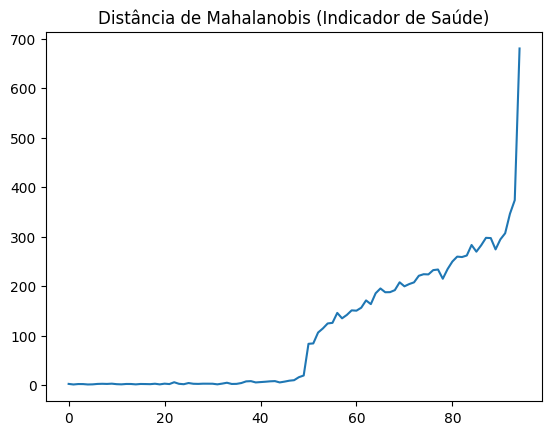

In [108]:
path = r"RS4/Bearing1_1.csv"
df = pd.read_csv(path)

# 1. Extração de características para todos os dados
features_vec = df.values

# 2. Divisão (agora com dimensões reduzidas, ex: 10 amostras x 5 features)
baseline_data = features_vec[:50] # Use um pouco mais que 10 se possível
all_data = features_vec[28:]

mean_ref = np.mean(baseline_data, axis=0)
cov_matrix = np.cov(baseline_data, rowvar=False)

# Adicionamos uma pequena regularização na diagonal para evitar matriz singular
cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-6
inv_cov = np.linalg.inv(cov_matrix)

# 3. Cálculo do Indicador
mhl = []
for data in all_data:
    # A distância de mahalanobis pode retornar o quadrado, 
    # usamos o cálculo manual para evitar o erro da raiz quadrada se preferir
    diff = data - mean_ref
    dist_sq = diff.T @ inv_cov @ diff
    mhl.append(np.sqrt(max(0, dist_sq))) # Garante que não seja negativo

plt.plot(mhl)
plt.title("Distância de Mahalanobis (Indicador de Saúde)")
plt.show()

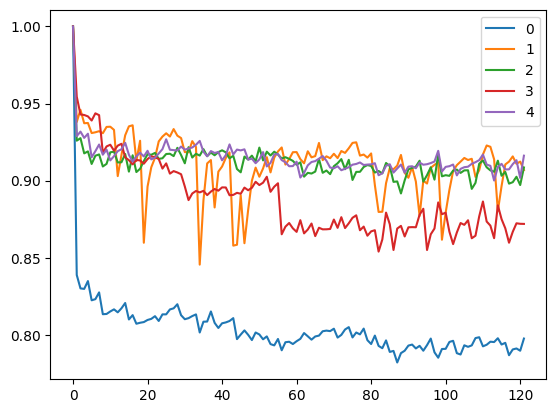

In [190]:
df2 = df**(1/2)
for col in df2.columns:
    plt.plot(df2[col],label=col)
plt.legend()

In [195]:
df1

,0,1,2,3,4
0,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.495061,0.774358,0.735066,0.829976,0.744401
2,0.474854,0.800661,0.740204,0.790606,0.753865
3,0.474100,0.771602,0.709211,0.789371,0.740810
4,0.485798,0.772156,0.713234,0.786350,0.749462
...,...,...,...,...,...
117,0.383162,0.692860,0.650473,0.546346,0.677702
118,0.390516,0.703181,0.653175,0.564509,0.687913
119,0.391763,0.688532,0.663497,0.579065,0.695611
120,0.388855,0.692897,0.647826,0.578215,0.661231


In [200]:
path = r"RS3/RSX3/Bearing1_4.csv"
df1 = pd.read_csv(path)
path = r"RS3/RSY3/Bearing1_4.csv"
df2 = pd.read_csv(path)
df = pd.concat([df1,df2],axis=1)
df

,0,1,2,3,4,0,1,2,3,4
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.495061,0.774358,0.735066,0.829976,0.744401,0.556862,0.777624,0.773083,0.780812,0.771855
2,0.474854,0.800661,0.740204,0.790606,0.753865,0.568397,0.756200,0.811451,0.787150,0.811582
3,0.474100,0.771602,0.709211,0.789371,0.740810,0.553050,0.796911,0.776108,0.780181,0.769106
4,0.485798,0.772156,0.713234,0.786350,0.749462,0.555662,0.767631,0.798803,0.781177,0.795549
...,...,...,...,...,...,...,...,...,...,...
117,0.383162,0.692860,0.650473,0.546346,0.677702,0.511251,0.774830,0.754673,0.752346,0.751662
118,0.390516,0.703181,0.653175,0.564509,0.687913,0.507795,0.768553,0.758257,0.765841,0.761465
119,0.391763,0.688532,0.663497,0.579065,0.695611,0.496046,0.766374,0.747680,0.772887,0.763323
120,0.388855,0.692897,0.647826,0.578215,0.661231,0.509936,0.750161,0.761377,0.764241,0.755299


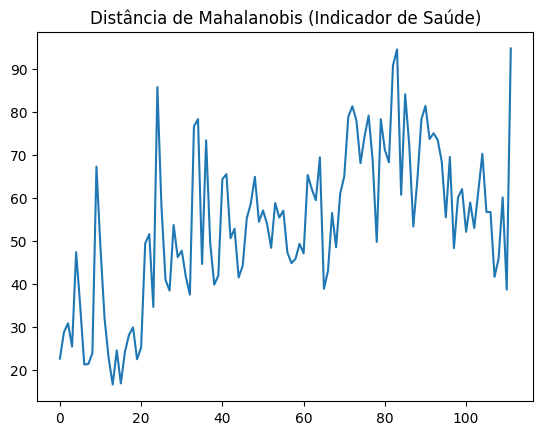

In [208]:
path = r"01_OBSOLETE/RS_R3/Bearing1_4.csv"
path = r"01_OBSOLETE/RSX4/Bearing1_4.csv"

path = r"RS3/RSX3/Bearing1_4.csv"
df1 = pd.read_csv(path)
path = r"RS3/RSY3/Bearing1_4.csv"
df2 = pd.read_csv(path)
df = pd.concat([df1,df2],axis=1)
n = 10
# 1. Extração de características para todos os dados
features_vec = df.iloc[:,:].values

# 2. Divisão (agora com dimensões reduzidas, ex: 10 amostras x 5 features)
baseline_data = features_vec[:n] # Use um pouco mais que 10 se possível
all_data = features_vec[n:]

mean_ref = np.mean(baseline_data, axis=0)
cov_matrix = np.cov(baseline_data, rowvar=False)

# Adicionamos uma pequena regularização na diagonal para evitar matriz singular
cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-6
inv_cov = np.linalg.inv(cov_matrix)

# 3. Cálculo do Indicador
mhl = []
for data in all_data:
    mhl.append(distance.mahalanobis(data,mean_ref,inv_cov)) # Garante que não seja negativo

plt.plot(mhl)
plt.title("Distância de Mahalanobis (Indicador de Saúde)")
plt.show()

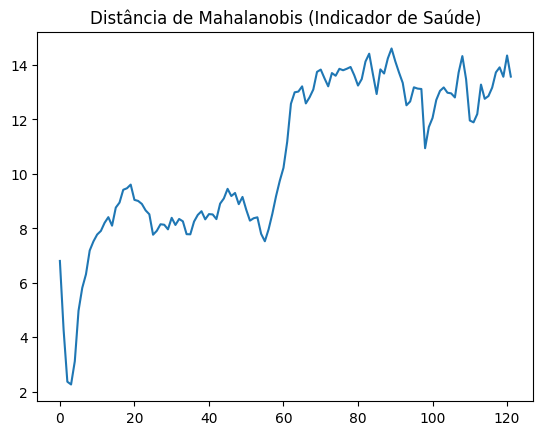

In [191]:
path = r"01_OBSOLETE/RSX4/Bearing1_4.csv"
df = pd.read_csv(path)
# 1. Extração de características para todos os dados
features_vec = df.values

all_data = features_vec[:]

mhl = []
for data in all_data:
    mhl.append(distance.mahalanobis(data,mean_ref,inv_cov)) # Garante que não seja negativo

plt.plot(mhl)
plt.title("Distância de Mahalanobis (Indicador de Saúde)")
plt.show()


In [ ]:
dir = r"01_OBSOLETE/RS_R2/"
failures = os.listdir(dir)
failures.sort()
mode = "Mode_3"
for failure in failures:
    brngs = os.listdir(dir+failure)
    brngs.sort()
    for brng in brngs:
        path = (dir+failure+'/'+brng)
        if brng.startswith('Bearing1_4'):
            df = pd.read_csv(path)
            plot_vector(df[mode].values, title=failure+" - " +brng+" - " +mode)


In [34]:
dir = r"/home/claudio/Área de trabalho/Python/DATASETS/VMD/02_VMDX_FFT/"
brngs = os.listdir(dir)
brngs.sort()
mode = 'Mode_1'
for brng in brngs:
    vec = []
    if brng.startswith("Bearing1_4"):
        samples = os.listdir(dir+brng)
        samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
        for sample in samples:
            df = pd.read_csv(dir+brng+"/"+sample)
            sig = df[mode].values

In [46]:
sig = (df.iloc[:,4].values)
plot_vector(sig)

In [ ]:
path = r"RS/RS_V3/RSX4_BPFI/"
RSs = os.listdir(path)
names = [[RS+f'_{i}' for i in range(5)] for RS in RSs]
brngs = os.listdir(path+RSs[0])
brngs.sort()
for brng in brngs:
    df = pd.DataFrame()
    for RS,name in zip(RSs, names):
        dff = pd.read_csv(path+RS+"/"+brng)
        dff.columns = name
        for col in dff.columns:
            df[col] = dff[col].values
    df.to_csv(path+brng, index=False)


In [22]:
path = r"RS3/"
RSs = os.listdir(path)
brngs = os.listdir(path+RSs[0])
brngs.sort()
for brng in brngs:
    df = pd.DataFrame()
    for RS in RSs:
        dff = pd.read_csv(path+RS+"/"+brng)
        vec = dff.iloc[:,0].values
        df[RS] = vec
    #df.to_csv(path+brng, index=False)


In [ ]:
path = r"RS/RS_V3/"
RSs = os.listdir(path)
RSs.sort()
names = [[RS+f'_{i}' for i in range(11)] for RS in RSs]
brngs = os.listdir(path+RSs[0])
brngs.sort()
for brng in brngs:
    for RS,name in zip(RSs, names):
        df = pd.read_csv(path+RS+"/"+brng)
        df.columns = name
        #df.to_csv(path+RS+"/"+brng, index=False)

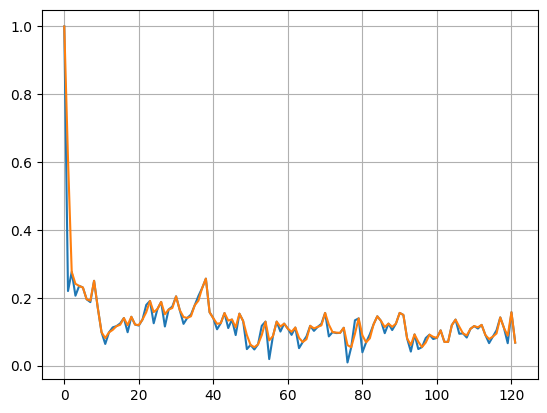

In [57]:
dfn = pd.DataFrame()
mid = int(len(df)/2)
for col in df.columns:
    vec = np.array([])
    sig = df[col].values
    check = [False for j in range(len(sig))]
    for i,val in enumerate(sig):
        vec = np.append(vec,val)
        if i>1:
            if sig[i] > sig[i-1] and not check[i-1]:
                vec[i-1] = (sig[i-1]+sig[i-2])*0.5
                check[i] = (True)
            

    dfn[col] = vec

plt.plot(df['RSY_CAGE_0'])
plt.plot(dfn['RSY_CAGE_0'])
plt.grid()

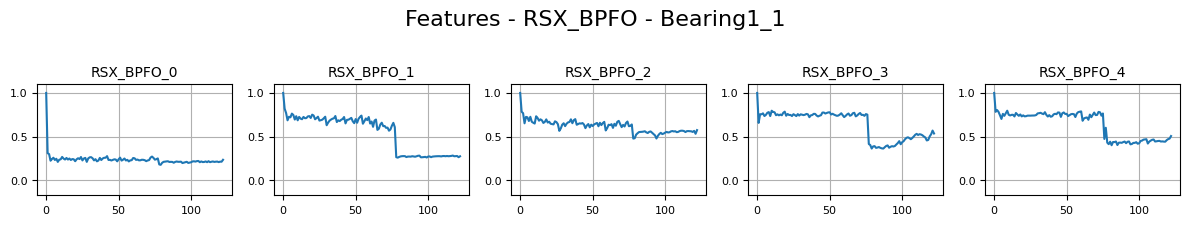

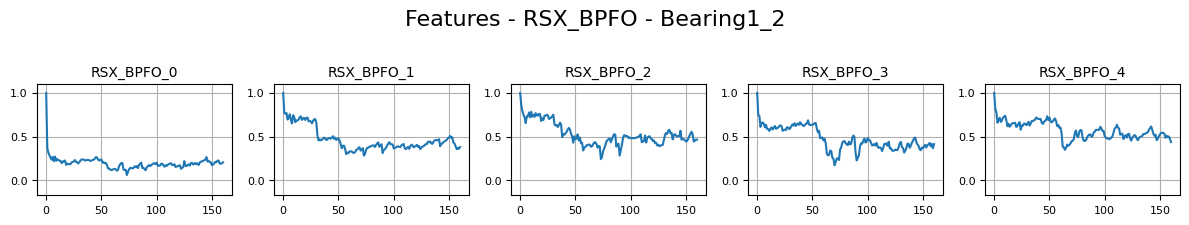

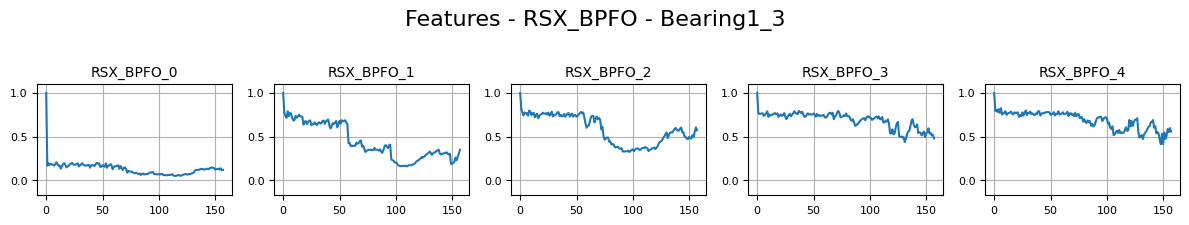

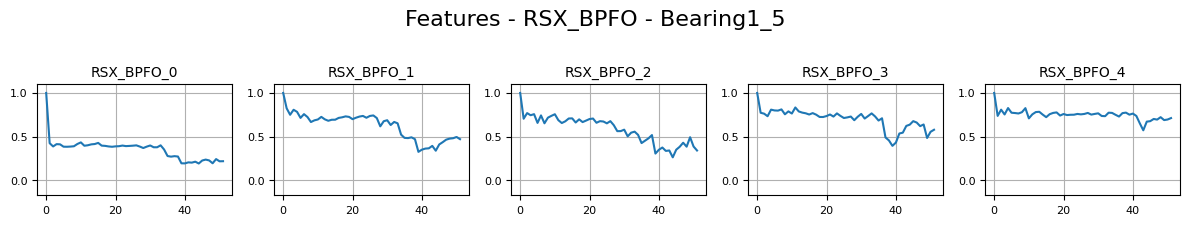

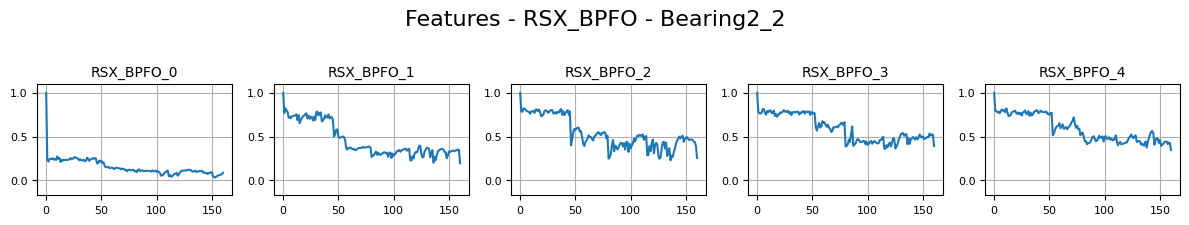

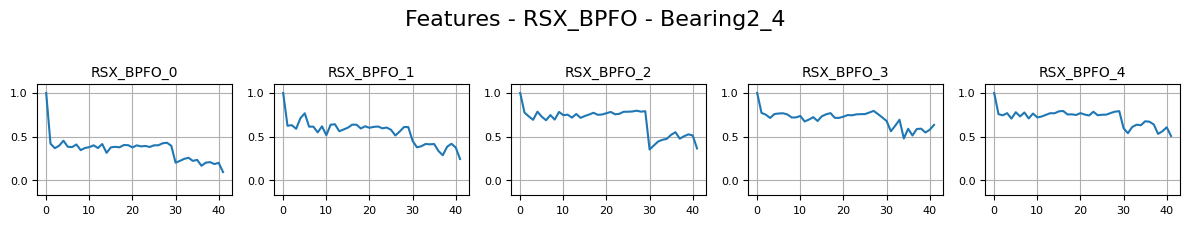

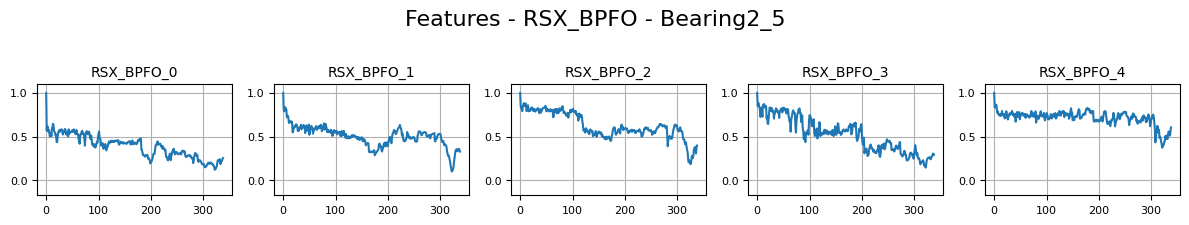

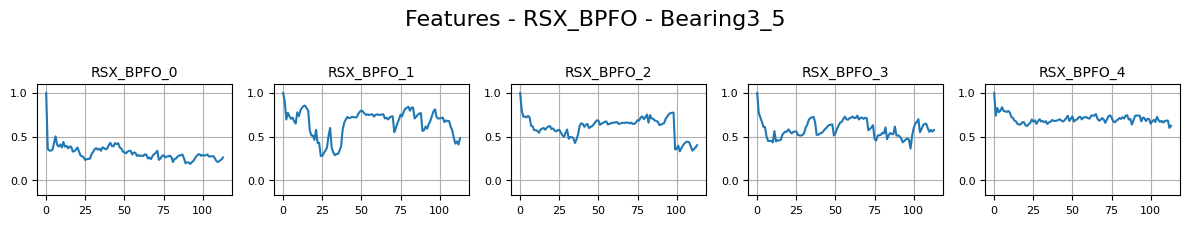

In [152]:
path, out = r"RS/RS_V3/", r"RS/RS_V3.1/"
RSs = os.listdir(path)
RSs.sort()
brngs = ['Bearing1_1.csv','Bearing1_2.csv','Bearing1_3.csv','Bearing1_5.csv','Bearing2_2.csv','Bearing2_4.csv','Bearing2_5.csv','Bearing3_5.csv']
#brngs = ['Bearing1_5.csv','Bearing2_1.csv','Bearing3_3.csv']
#brngs = ['Bearing1_4.csv', 'Bearing2_3.csv']
for brng in brngs[:]:
    if not brng.startswith("Bearing5_1"):
        for RS in (RSs):
            if RS.endswith("RSX_BPFO"):
                df = pd.read_csv(path+RS+"/"+brng)
                #df = df - df.mean()
                #df = smooth_df(df,3)
                plot_features(df.iloc[:,:5],5,RS+" - "+brng,w=12,h=2.25,ylim=[-0.17,1.1])

In [156]:
path, out = r"RS/RS_V3/", r"RS/RS_V3_D1/"
modes = os.listdir(path)
modes.sort()
brngs = os.listdir(path+modes[0])
brngs.sort()
for brng in brngs[:]:
    dff = pd.DataFrame()
    if not brng.startswith("Bearing5_1"):
        for mode in (modes):
            df = pd.read_csv(path+mode+"/"+brng)
            col = mode_select(mode)
            dff[col] = df[col].values
    dff.to_csv(out+brng, index = False)
             

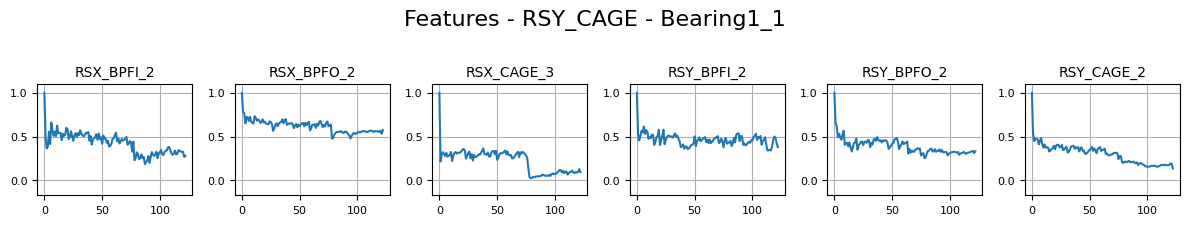

In [145]:
plot_features(dff.iloc[:,:],6,RS+" - "+brng,w=12,h=2.25,ylim=[-0.17,1.1])

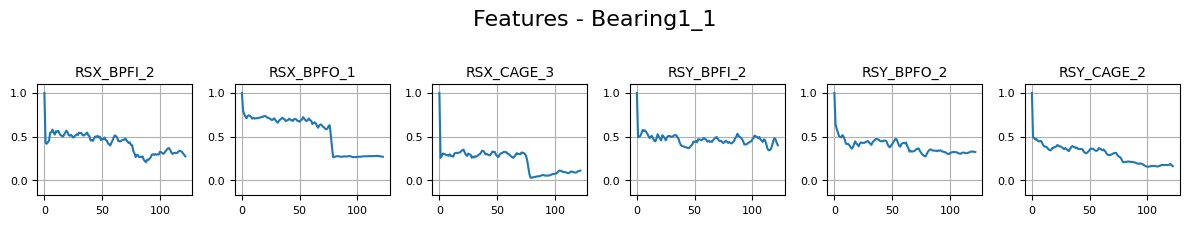

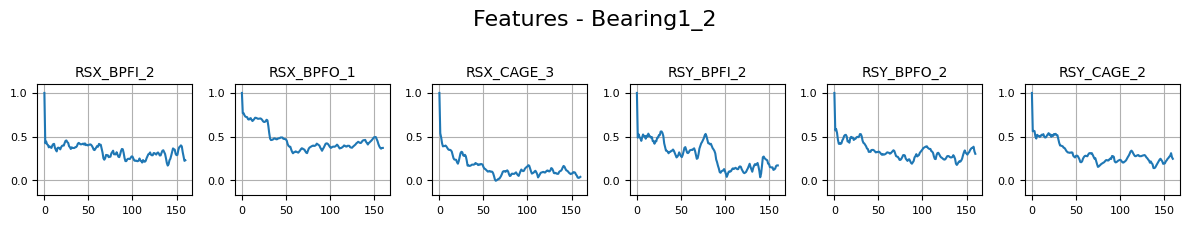

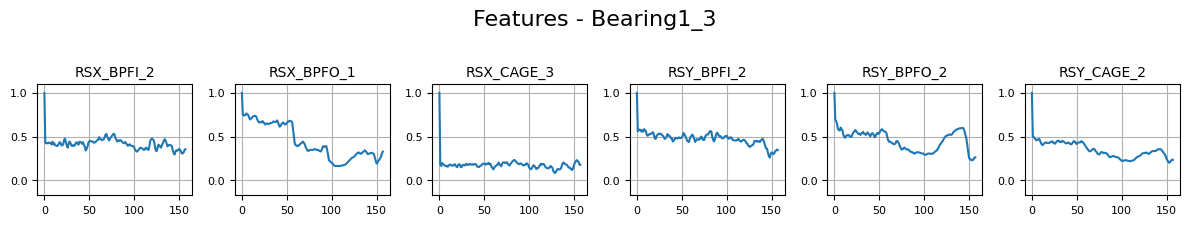

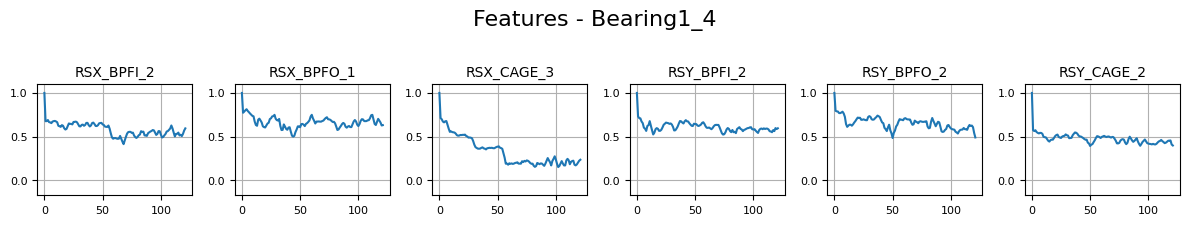

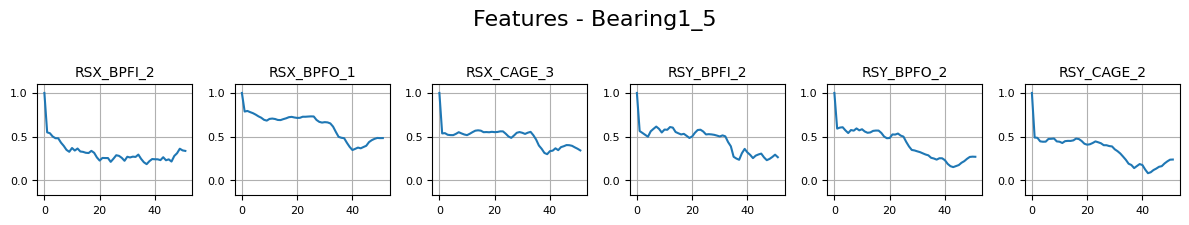

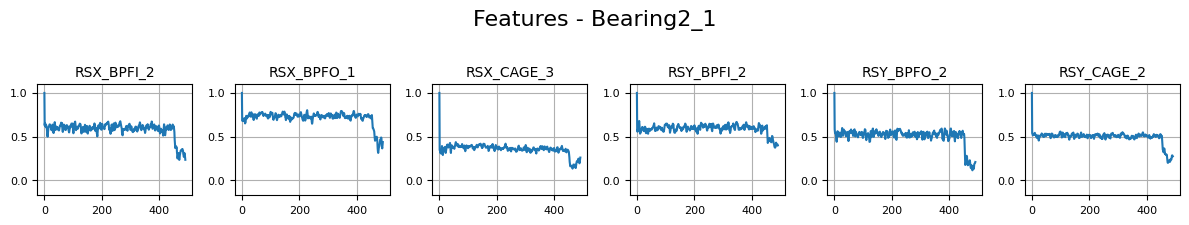

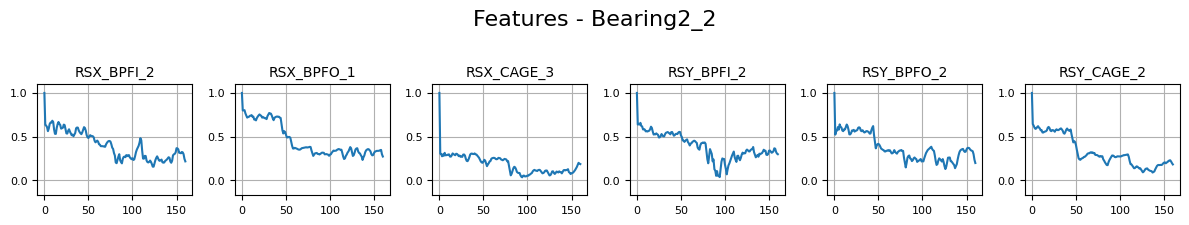

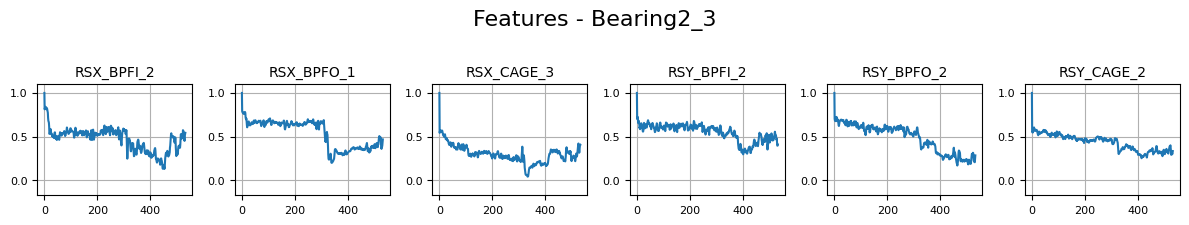

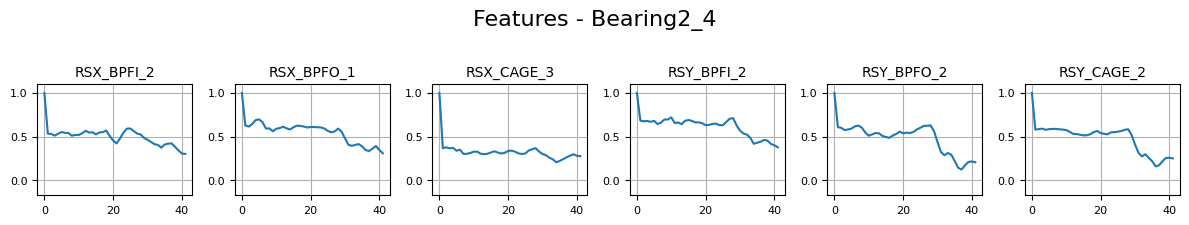

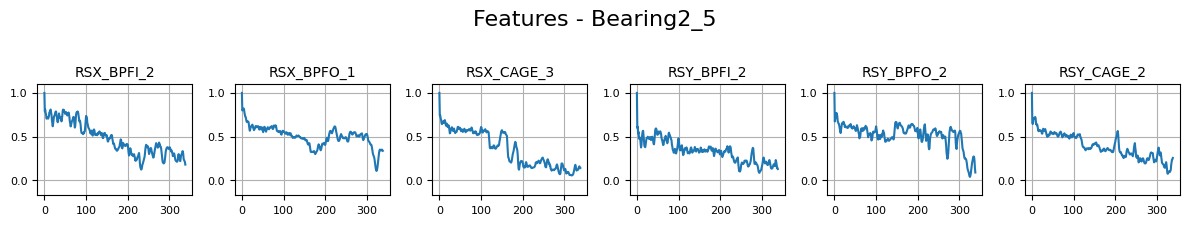

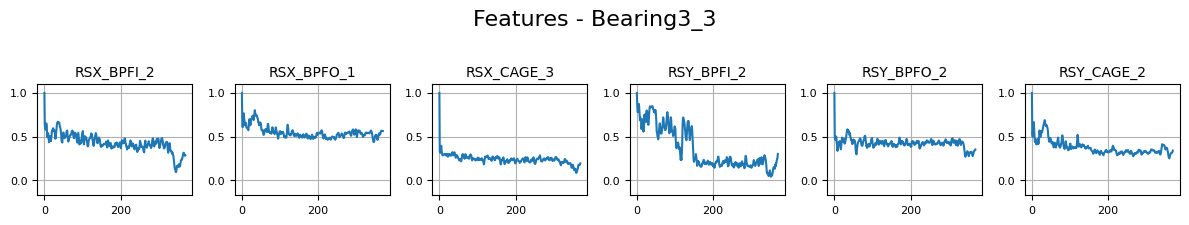

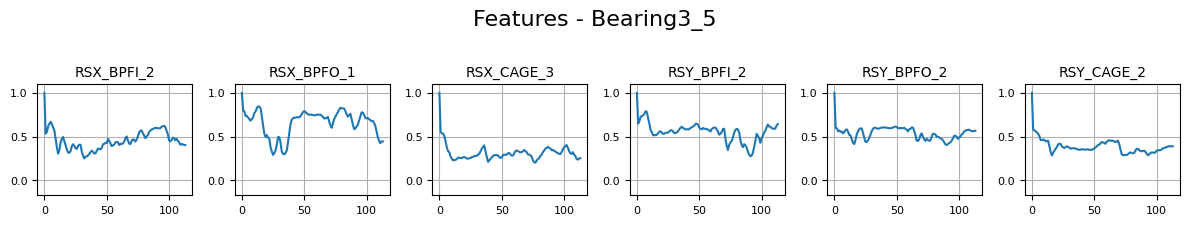

In [157]:
path = r"RS/RS_V3_D1/"
brngs = os.listdir(path)
brngs.sort()
for brng in brngs[:]:
    df = pd.read_csv(path+brng)
    df = smooth_df(df,3)
    plot_features(df.iloc[:,:6],6,brng,w=12,h=2.25,ylim=[-0.17,1.1])